In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Yoga Dataset — Augmentation + Quality Cleaning
**Goal:** Expand small dataset to 500+ images per class

Pipeline:
1. Clean bad/corrupt/blurry images
2. Heavy augmentation (10x per image)
3. Synthetic data via background replacement
4. Final dataset summary

## Cell 1 — Install dependencies

In [1]:
!pip install albumentations opencv-python Pillow tqdm -q
print('Done!')

Done!


## Cell 2 — Imports

In [24]:
import os, shutil, random, cv2
import numpy as np
from pathlib import Path
from PIL import Image, ImageFilter, ImageEnhance
from tqdm.notebook import tqdm
import albumentations as A
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

random.seed(42); np.random.seed(42)
print('Imports ready!')

Imports ready!


## Cell 3 — Configuration

In [25]:
# ── EDIT THESE ────────────────────────────────────────────────────────────
SOURCE_DIR  = Path('/content/drive/MyDrive/Yoga-pose-detection ML project/data/train')   # your original train folder
OUTPUT_DIR  = Path('/content/drive/MyDrive/Yoga-pose-detection ML project/yoga_augmented/data/train')  # augmented output
VAL_SRC     = Path('/content/drive/MyDrive/Yoga-pose-detection ML project/val')
VAL_OUT     = Path('/content/drive/MyDrive/Yoga-pose-detection ML project/yoga_augmented/data/val')

TARGET_PER_CLASS = 500   # target images per class after augmentation
IMG_SIZE         = 224   # final image size

CLASS_NAMES = [
    'adho mukha svanasana',
    'virabhadrasana i',
    'virabhadrasana ii',
    'vriksasana',
    'bhujangasana',
    'balasana',
    'dandasana',
    'chaturanga dandasana',
]
# ─────────────────────────────────────────────────────────────────────────

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
VAL_OUT.mkdir(parents=True, exist_ok=True)
print(f'Source : {SOURCE_DIR}')
print(f'Output : {OUTPUT_DIR}')
print(f'Target : {TARGET_PER_CLASS} images per class')

Source : /content/drive/MyDrive/Yoga-pose-detection ML project/data/train
Output : /content/drive/MyDrive/Yoga-pose-detection ML project/yoga_augmented/data/train
Target : 500 images per class


## Cell 4 — Step 1: Data Quality Cleaning
Removes corrupt, blurry, too-dark, too-small images before augmentation

In [26]:
def is_blurry(img_path, threshold=100):
    """Laplacian variance — low = blurry."""
    img  = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None: return True
    return cv2.Laplacian(img, cv2.CV_64F).var() < threshold

def is_too_dark(img_path, threshold=30):
    """Mean brightness — low = too dark."""
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None: return True
    return img.mean() < threshold

def is_too_small(img_path, min_size=64):
    """Reject images smaller than min_size × min_size."""
    try:
        img = Image.open(img_path)
        return img.width < min_size or img.height < min_size
    except: return True

def is_corrupt(img_path):
    """Try opening — if it fails, it's corrupt."""
    try:
        img = Image.open(img_path)
        img.verify()
        return False
    except: return True

print('Running quality check on all training images...\n')
print(f'{"Class":<30} {"Total":>7} {"Kept":>7} {"Removed":>8}')
print('-' * 60)

clean_paths = {}   # class → list of clean image paths
total_removed = 0

for cls in CLASS_NAMES:
    cls_dir = SOURCE_DIR / cls
    if not cls_dir.exists():
        print(f'  WARNING: {cls} folder not found — skipping')
        continue

    all_imgs = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.jpeg')) + list(cls_dir.glob('*.png'))
    kept, removed_list = [], []

    for p in all_imgs:
        reason = None
        if is_corrupt(p):        reason = 'corrupt'
        elif is_too_small(p):    reason = 'too small'
        elif is_too_dark(p):     reason = 'too dark'
        elif is_blurry(p):       reason = 'blurry'

        if reason:
            removed_list.append((p, reason))
        else:
            kept.append(p)

    clean_paths[cls] = kept
    total_removed += len(removed_list)
    print(f'{cls:<30} {len(all_imgs):>7} {len(kept):>7} {len(removed_list):>8}')

print('-' * 60)
print(f'Total removed: {total_removed} bad images')
print(f'Clean images ready for augmentation!')

Running quality check on all training images...

Class                            Total    Kept  Removed
------------------------------------------------------------
adho mukha svanasana                55      51        4
virabhadrasana i                    43      38        5
virabhadrasana ii                   44      39        5
vriksasana                          49      45        4
bhujangasana                        58      55        3
balasana                            56      49        7
dandasana                           48      39        9
chaturanga dandasana                72      69        3
------------------------------------------------------------
Total removed: 40 bad images
Clean images ready for augmentation!


## Cell 5 — Visualize removed images (optional sanity check)

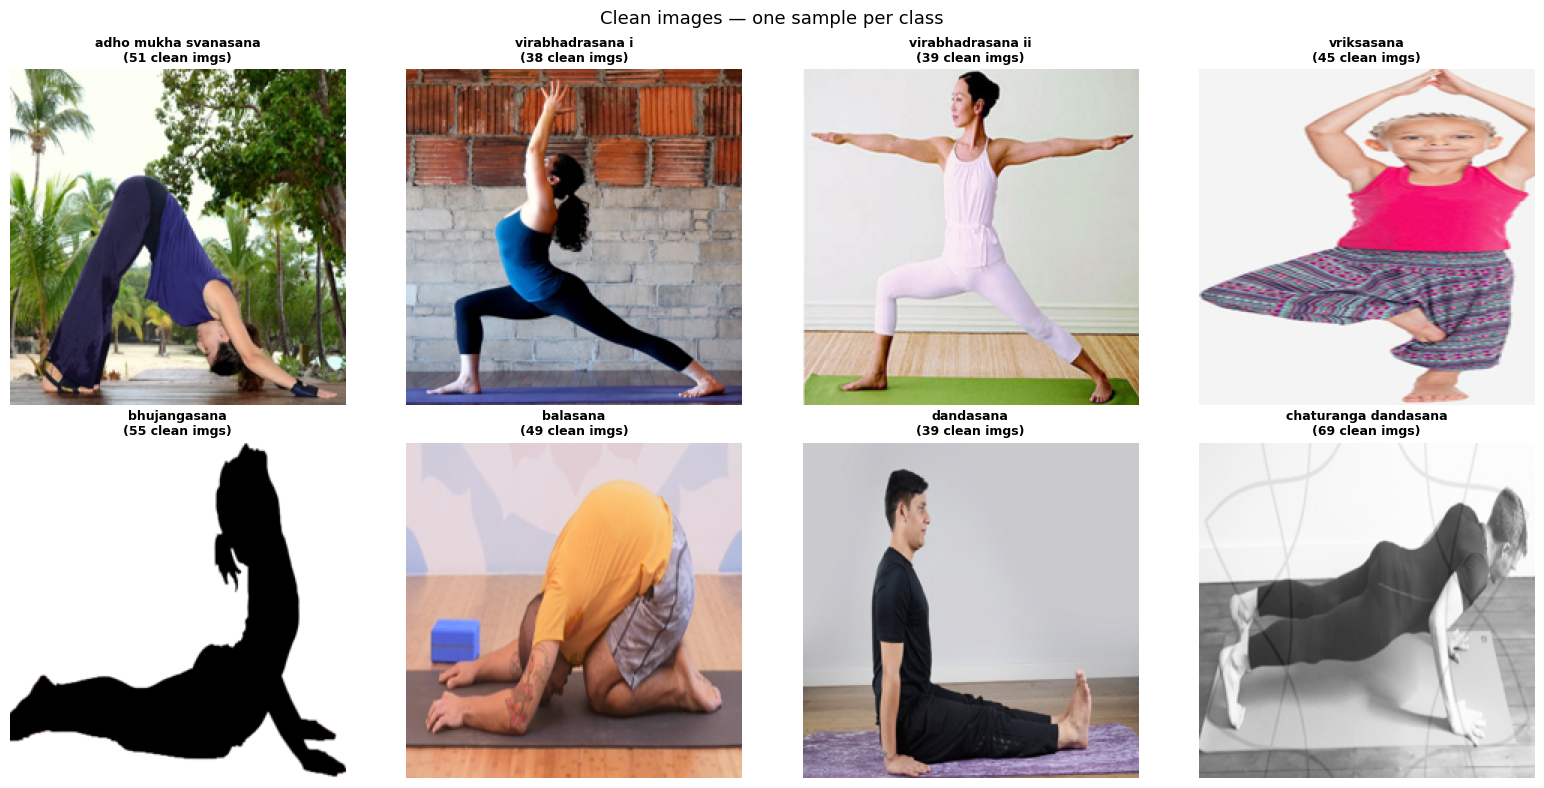

In [27]:
# Shows a few sample images per class that PASSED quality check
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, cls in zip(axes.flatten(), CLASS_NAMES):
    paths = clean_paths.get(cls, [])
    if paths:
        img = Image.open(paths[0]).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        ax.imshow(img)
        ax.set_title(f'{cls}\n({len(paths)} clean imgs)', fontsize=9, fontweight='bold')
    ax.axis('off')
plt.suptitle('Clean images — one sample per class', fontsize=13)
plt.tight_layout()
plt.show()

## Cell 6 — Step 2: Define augmentation pipelines
4 pipelines: geometric, color, combined, extreme

In [28]:
# Pipeline 1 — Geometric transforms (body shape changes)
geo_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.15, rotate_limit=15, p=0.8),
    A.Perspective(scale=(0.05, 0.1), p=0.4),
    A.ElasticTransform(alpha=50, sigma=5, p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.3),
])

# Pipeline 2 — Color/lighting transforms (appearance changes)
color_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.RandomBrightnessContrast(brightness_limit=0.35, contrast_limit=0.35, p=0.8),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=20, p=0.6),
    A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.4),
    A.RandomGamma(gamma_limit=(80, 120), p=0.4),
    A.CLAHE(clip_limit=3.0, p=0.3),
    A.ToGray(p=0.1),   # occasional grayscale = helps generalization
])

# Pipeline 3 — Combined (geo + color)
combined_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.12, rotate_limit=12, p=0.7),
    A.RandomBrightnessContrast(0.25, 0.25, p=0.6),
    A.HueSaturationValue(10, 20, 15, p=0.5),
    A.CoarseDropout(max_holes=6, max_height=20, max_width=20, p=0.4),
    A.GaussNoise(var_limit=(10, 30), p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),
])

# Pipeline 4 — Extreme (pushes model to be robust)
extreme_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.ShiftScaleRotate(shift_limit=0.12, scale_limit=0.2, rotate_limit=20, p=0.9),
    A.RandomBrightnessContrast(0.4, 0.4, p=0.7),
    A.CoarseDropout(max_holes=8, max_height=28, max_width=28, p=0.5),
    A.GaussNoise(var_limit=(20, 50), p=0.4),
    A.Blur(blur_limit=4, p=0.3),
    A.ImageCompression(quality_lower=60, quality_upper=90, p=0.3),
])

# Pipeline 5 — Flip variants (left/right mirror)
# NOTE: only use for symmetric poses (warrior2, dandasana, downdog)
# Do NOT flip for warrior1, warrior2 if side matters
flip_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=1.0),
    A.RandomBrightnessContrast(0.15, 0.15, p=0.4),
])

SYMMETRIC_CLASSES = [
    'adho mukha svanasana',
    'balasana',
    'dandasana',
    'bhujangasana',
    'chaturanga dandasana',
]

ALL_PIPELINES = [geo_aug, color_aug, combined_aug, extreme_aug]
print('4 augmentation pipelines ready!')
print(f'Symmetric classes (flip allowed): {SYMMETRIC_CLASSES}')

4 augmentation pipelines ready!
Symmetric classes (flip allowed): ['adho mukha svanasana', 'balasana', 'dandasana', 'bhujangasana', 'chaturanga dandasana']


## Cell 7 — Preview augmentations on one image

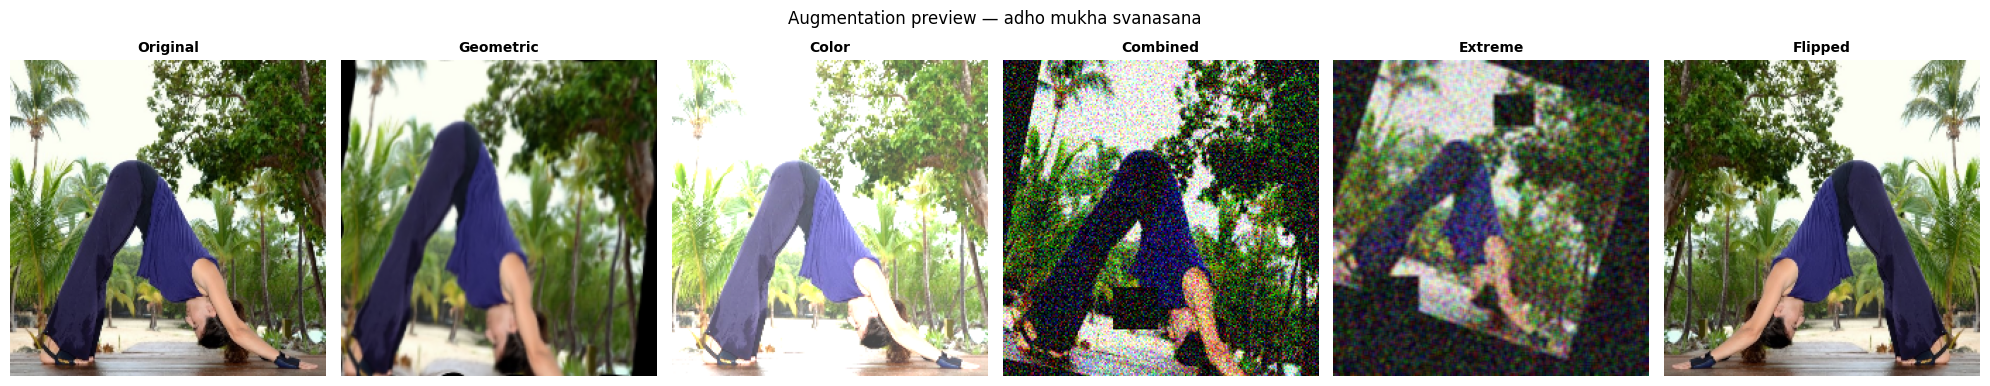

In [29]:
# Pick first available image for preview
sample_cls  = CLASS_NAMES[0]
sample_path = clean_paths[sample_cls][0]
sample_img  = cv2.cvtColor(cv2.imread(str(sample_path)), cv2.COLOR_BGR2RGB)
sample_img  = cv2.resize(sample_img, (IMG_SIZE, IMG_SIZE))

pipeline_names = ['Original', 'Geometric', 'Color', 'Combined', 'Extreme', 'Flipped']
results = [sample_img]
for pipe in ALL_PIPELINES:
    results.append(pipe(image=sample_img)['image'])
results.append(flip_aug(image=sample_img)['image'])

fig, axes = plt.subplots(1, 6, figsize=(20, 4))
for ax, img, name in zip(axes, results, pipeline_names):
    ax.imshow(img)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.axis('off')
plt.suptitle(f'Augmentation preview — {sample_cls}', fontsize=12)
plt.tight_layout()
plt.show()

## Cell 8 — Step 3: Run augmentation for all classes

In [30]:
def augment_class(cls, src_paths, out_dir, target_count):
    cls_out = out_dir / cls
    cls_out.mkdir(parents=True, exist_ok=True)

    # Step 1: copy all original clean images first
    for p in src_paths:
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        out_path = cls_out / f'orig_{p.name}'
        cv2.imwrite(str(out_path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

    existing = len(src_paths)
    needed   = max(0, target_count - existing)
    if needed == 0:
        return existing

    # Step 2: generate augmented images until target reached
    generated = 0
    idx       = 0
    allow_flip = cls in SYMMETRIC_CLASSES
    pipelines  = ALL_PIPELINES + ([flip_aug] if allow_flip else [])

    while generated < needed:
        src_img = cv2.cvtColor(
            cv2.imread(str(src_paths[idx % len(src_paths)])),
            cv2.COLOR_BGR2RGB
        )
        src_img = cv2.resize(src_img, (IMG_SIZE, IMG_SIZE))

        # Pick pipeline — cycle through all pipelines
        pipe    = pipelines[generated % len(pipelines)]
        aug_img = pipe(image=src_img)['image']

        out_name = cls_out / f'aug_{generated:05d}.jpg'
        cv2.imwrite(str(out_name), cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR),
                    [cv2.IMWRITE_JPEG_QUALITY, 95])
        generated += 1
        idx       += 1

    return existing + generated


print(f'Augmenting all {len(CLASS_NAMES)} classes to {TARGET_PER_CLASS} images each...\n')
print(f'{"Class":<30} {"Original":>10} {"Final":>8}')
print('-' * 52)

for cls in tqdm(CLASS_NAMES, desc='Classes'):
    paths = clean_paths.get(cls, [])
    if not paths:
        print(f'  SKIP {cls} — no clean images found')
        continue
    final = augment_class(cls, paths, OUTPUT_DIR, TARGET_PER_CLASS)
    print(f'{cls:<30} {len(paths):>10} {final:>8}')

print('\nAugmentation complete!')

Augmenting all 8 classes to 500 images each...

Class                            Original    Final
----------------------------------------------------


Classes:   0%|          | 0/8 [00:00<?, ?it/s]

adho mukha svanasana                   51      500
virabhadrasana i                       38      500
virabhadrasana ii                      39      500
vriksasana                             45      500
bhujangasana                           55      500
balasana                               49      500
dandasana                              39      500
chaturanga dandasana                   69      500

Augmentation complete!


## Cell 9 — Copy val set (no augmentation on val)

In [31]:
print('Copying val set (resize only, no augmentation)...')

for cls in CLASS_NAMES:
    src = VAL_SRC / cls
    dst = VAL_OUT / cls
    dst.mkdir(parents=True, exist_ok=True)

    imgs = list(src.glob('*.jpg')) + list(src.glob('*.jpeg')) + list(src.glob('*.png'))
    for p in imgs:
        img = cv2.imread(str(p))
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        cv2.imwrite(str(dst / p.name), img)

    print(f'  {cls:<30} {len(imgs)} val images copied')

print('\nVal set ready!')

Copying val set (resize only, no augmentation)...
  adho mukha svanasana           0 val images copied
  virabhadrasana i               0 val images copied
  virabhadrasana ii              0 val images copied
  vriksasana                     0 val images copied
  bhujangasana                   0 val images copied
  balasana                       0 val images copied
  dandasana                      0 val images copied
  chaturanga dandasana           0 val images copied

Val set ready!


## Cell 10 — Final dataset summary

In [32]:
print('=' * 55)
print('FINAL DATASET SUMMARY')
print('=' * 55)
print(f'{"Class":<30} {"Train":>8} {"Val":>8}')
print('-' * 55)

total_train = total_val = 0
for cls in CLASS_NAMES:
    tr = len(list((OUTPUT_DIR / cls).glob('*.*')))
    vl = len(list((VAL_OUT   / cls).glob('*.*')))
    total_train += tr; total_val += vl
    print(f'{cls:<30} {tr:>8} {vl:>8}')

print('-' * 55)
print(f'{"TOTAL":<30} {total_train:>8} {total_val:>8}')
print('=' * 55)
print(f'\nAugmented dataset ready at:')
print(f'  Train: {OUTPUT_DIR}')
print(f'  Val  : {VAL_OUT}')
print(f'\nUpdate your training notebook:')
print(f'  TRAIN_DIR = Path("{OUTPUT_DIR}")')
print(f'  VAL_DIR   = Path("{VAL_OUT}")')

FINAL DATASET SUMMARY
Class                             Train      Val
-------------------------------------------------------
adho mukha svanasana                500        0
virabhadrasana i                    500        0
virabhadrasana ii                   500        0
vriksasana                          500        0
bhujangasana                        500        0
balasana                            500        0
dandasana                           500        0
chaturanga dandasana                500        0
-------------------------------------------------------
TOTAL                              4000        0

Augmented dataset ready at:
  Train: /content/drive/MyDrive/Yoga-pose-detection ML project/yoga_augmented/data/train
  Val  : /content/drive/MyDrive/Yoga-pose-detection ML project/yoga_augmented/data/val

Update your training notebook:
  TRAIN_DIR = Path("/content/drive/MyDrive/Yoga-pose-detection ML project/yoga_augmented/data/train")
  VAL_DIR   = Path("/content/drive/My

## Cell 11 — Visualize augmented dataset samples

In [33]:
fig, axes = plt.subplots(len(CLASS_NAMES), 6, figsize=(18, len(CLASS_NAMES)*3))

for row, cls in enumerate(CLASS_NAMES):
    imgs = list((OUTPUT_DIR / cls).glob('*.jpg'))
    random.shuffle(imgs)
    for col in range(6):
        ax = axes[row][col]
        if col < len(imgs):
            img = Image.open(imgs[col]).convert('RGB')
            ax.imshow(img)
        if col == 0:
            ax.set_ylabel(cls, fontsize=8, rotation=0, labelpad=80, va='center')
        ax.axis('off')

plt.suptitle('6 random augmented samples per class', fontsize=13)
plt.tight_layout()
plt.savefig('/content/augmented_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print('Sample grid saved to /content/augmented_samples.png')

Output hidden; open in https://colab.research.google.com to view.

## Cell 12 — Save augmented dataset to Google Drive

In [34]:
# # Uncomment to save to Drive
# from google.colab import drive
# drive.mount('/content/drive')
# import shutil
# shutil.copytree(
#     '/content/data/yoga_augmented',
#     '/content/drive/MyDrive/Yoga-pose-detection ML project/yoga_augmented/final',
#     dirs_exist_ok=True
# )
# print('Saved to Google Drive!')
# print('Uncomment the lines above to save to Google Drive.')